# **전처리 단계 시각화 코드**

전처리 과정
- 1. 불량 다이 좌표 추출
- 2. 정규화
- 3. DBSCAN 노이즈 제거
- 4. 극좌표계 변환

시각화
- 1단계, 2단계, 3단계에 해당하는 전처리 과정 시각화
- 행렬 크기가 각각 다른 웨이퍼들을 불량 패턴 별로 시각화

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

불량 데이터셋 로드 중...


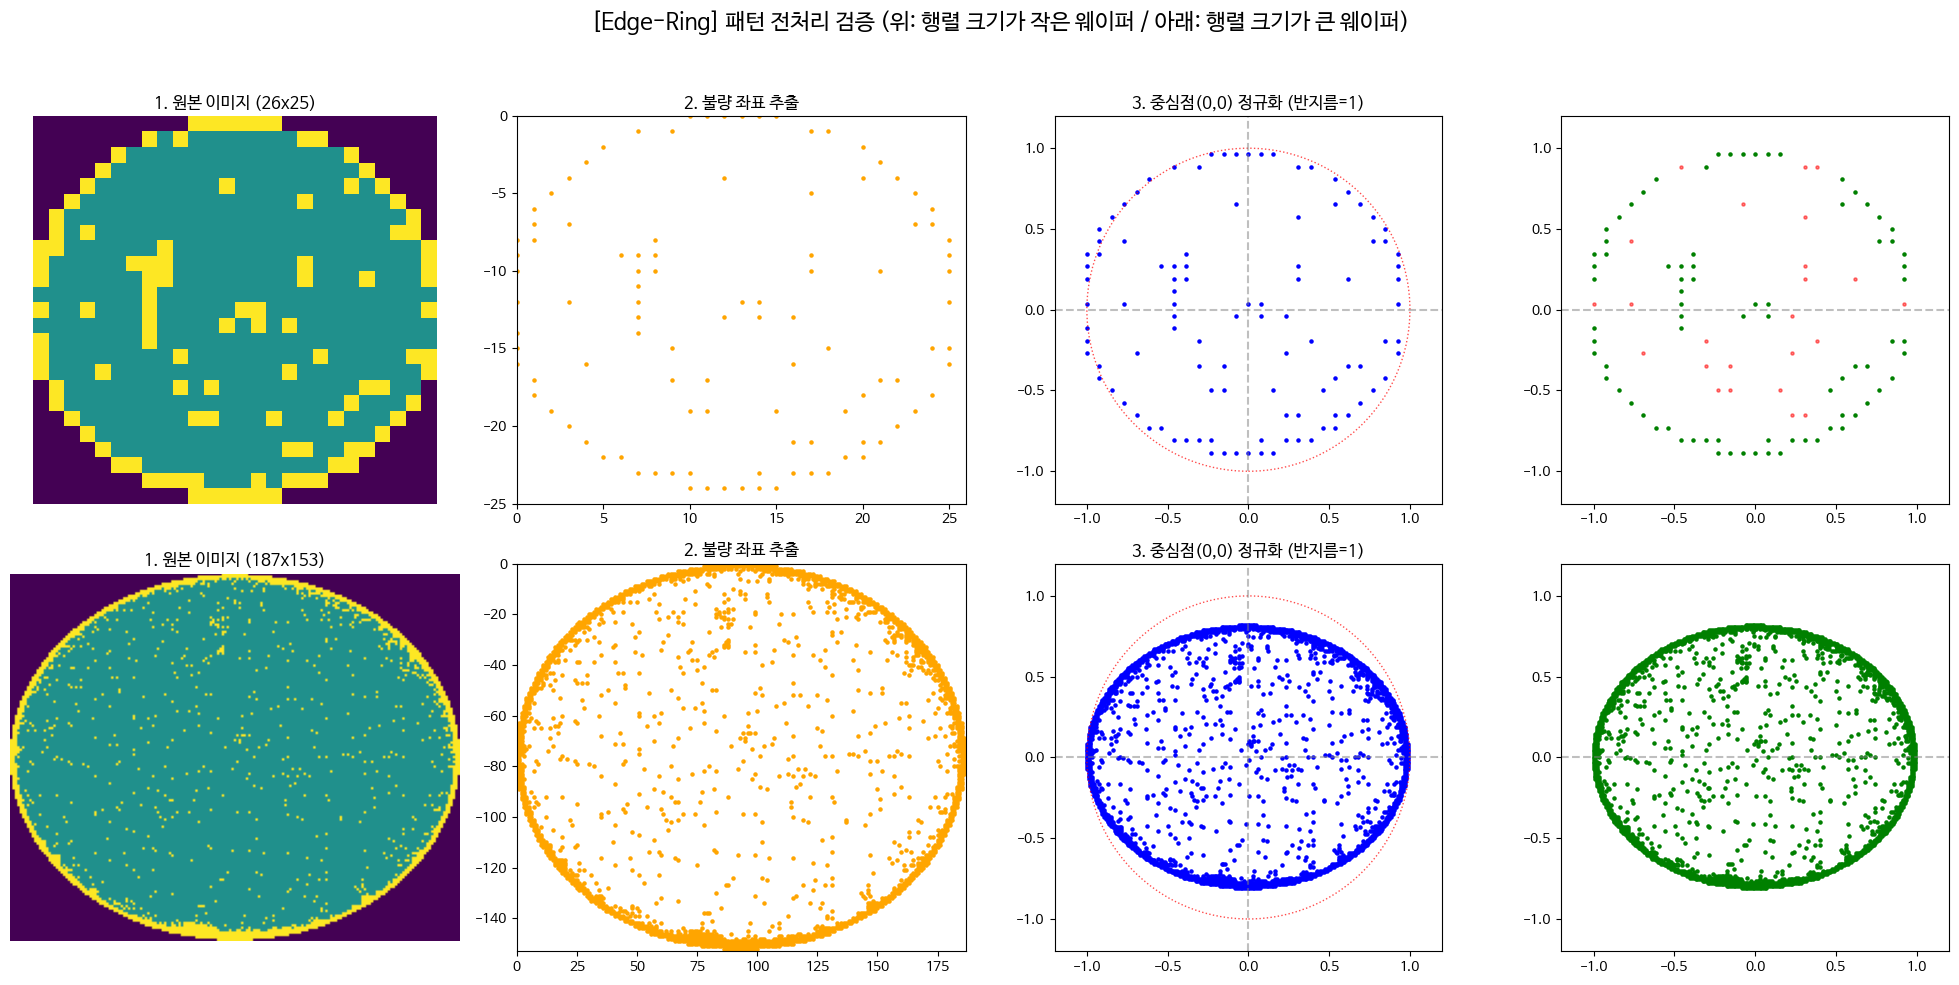

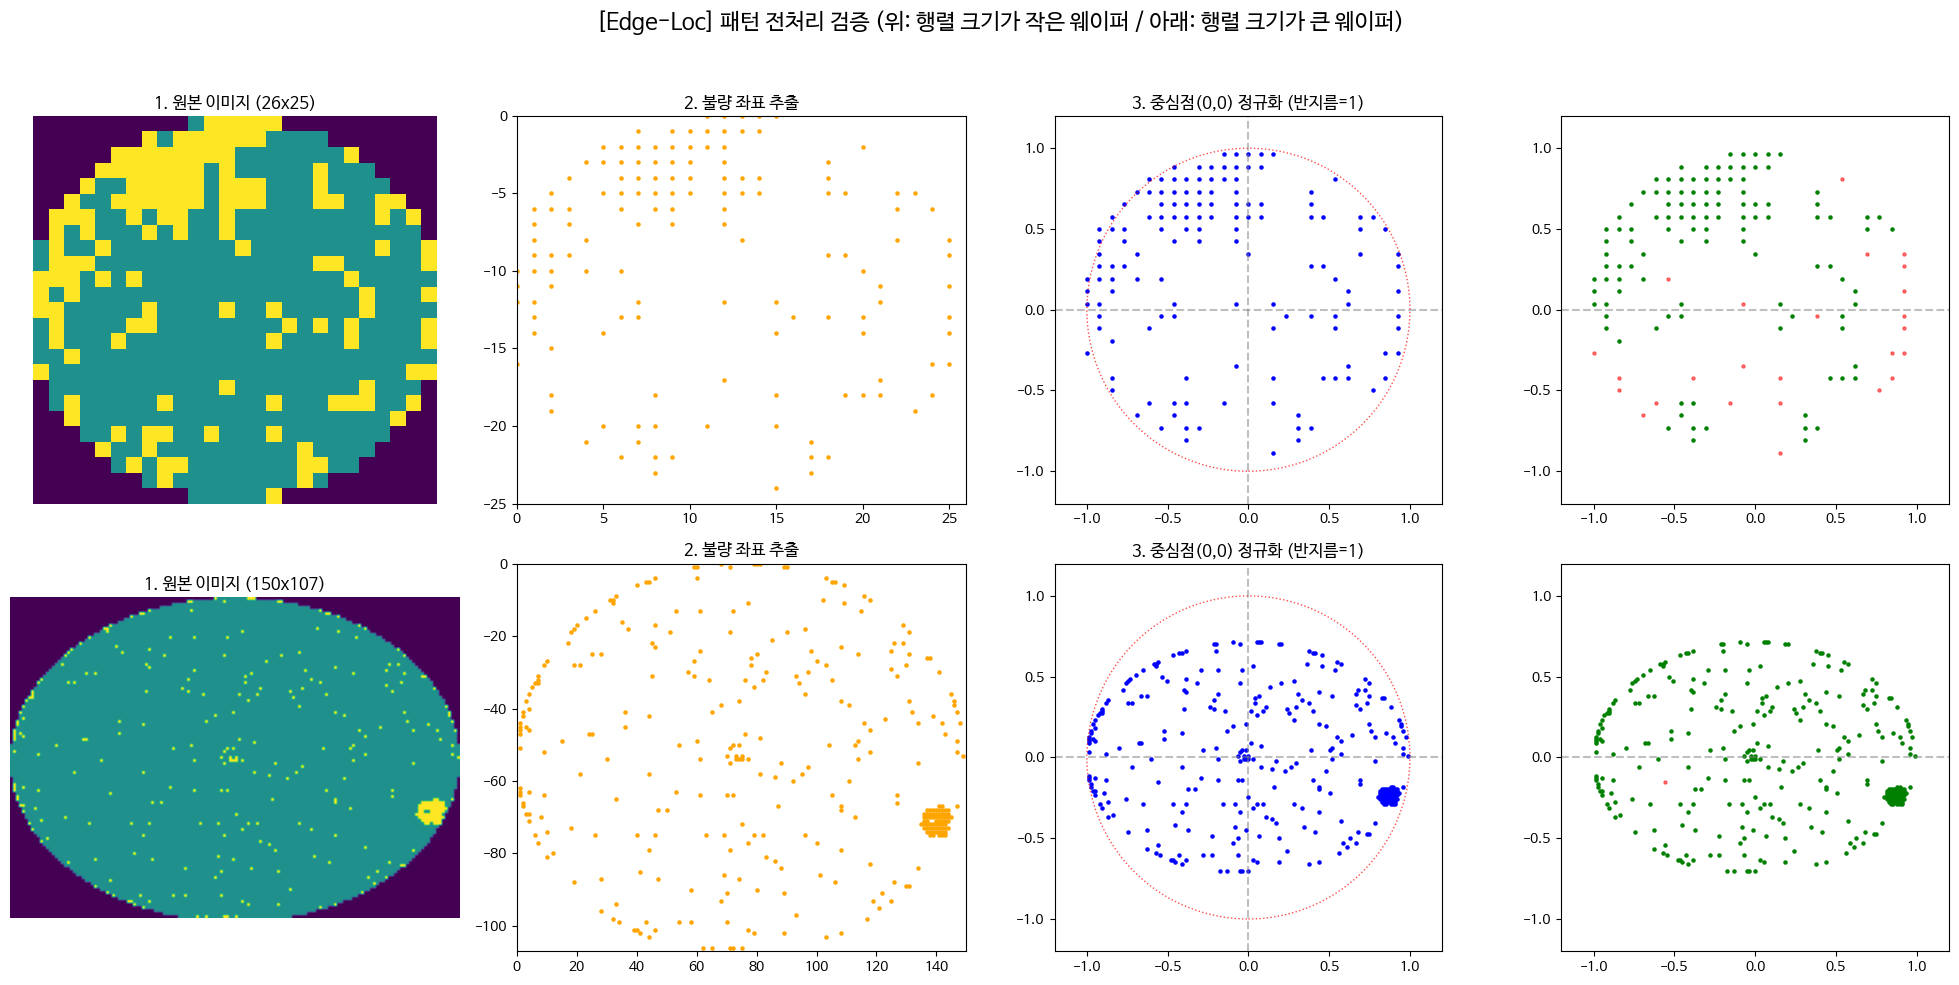

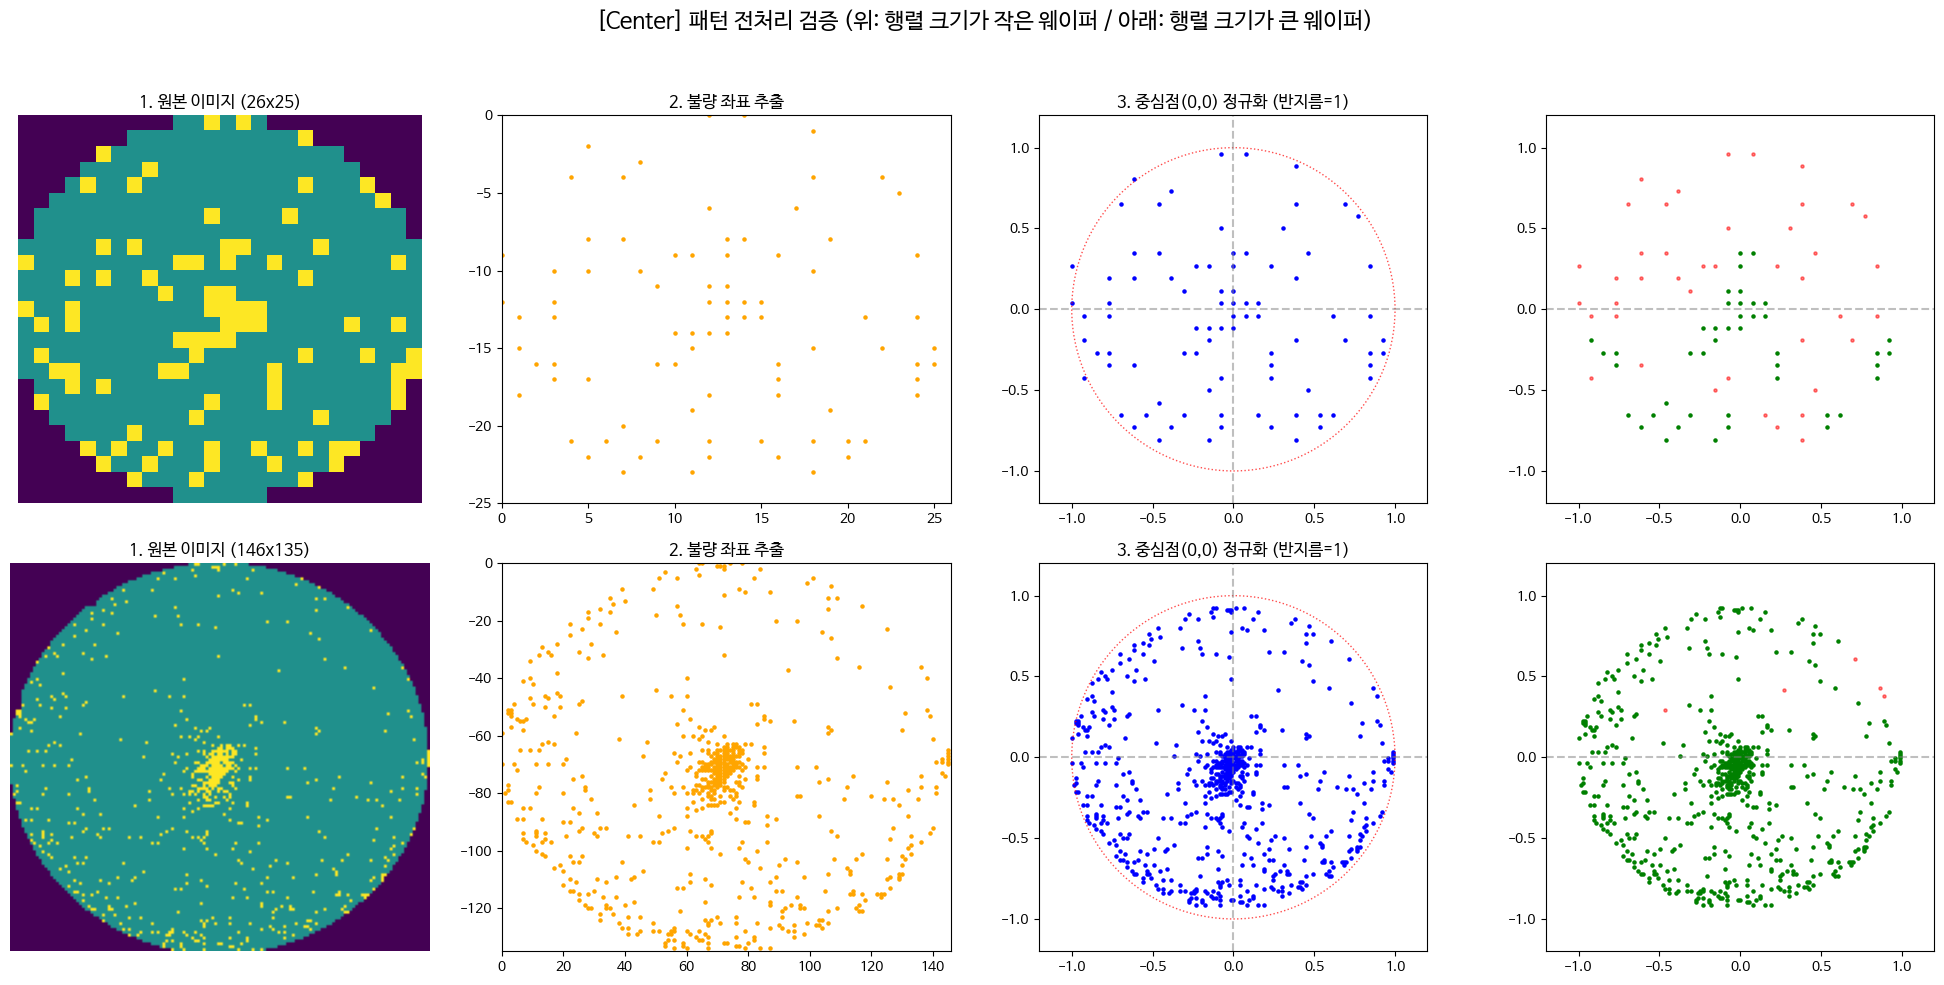

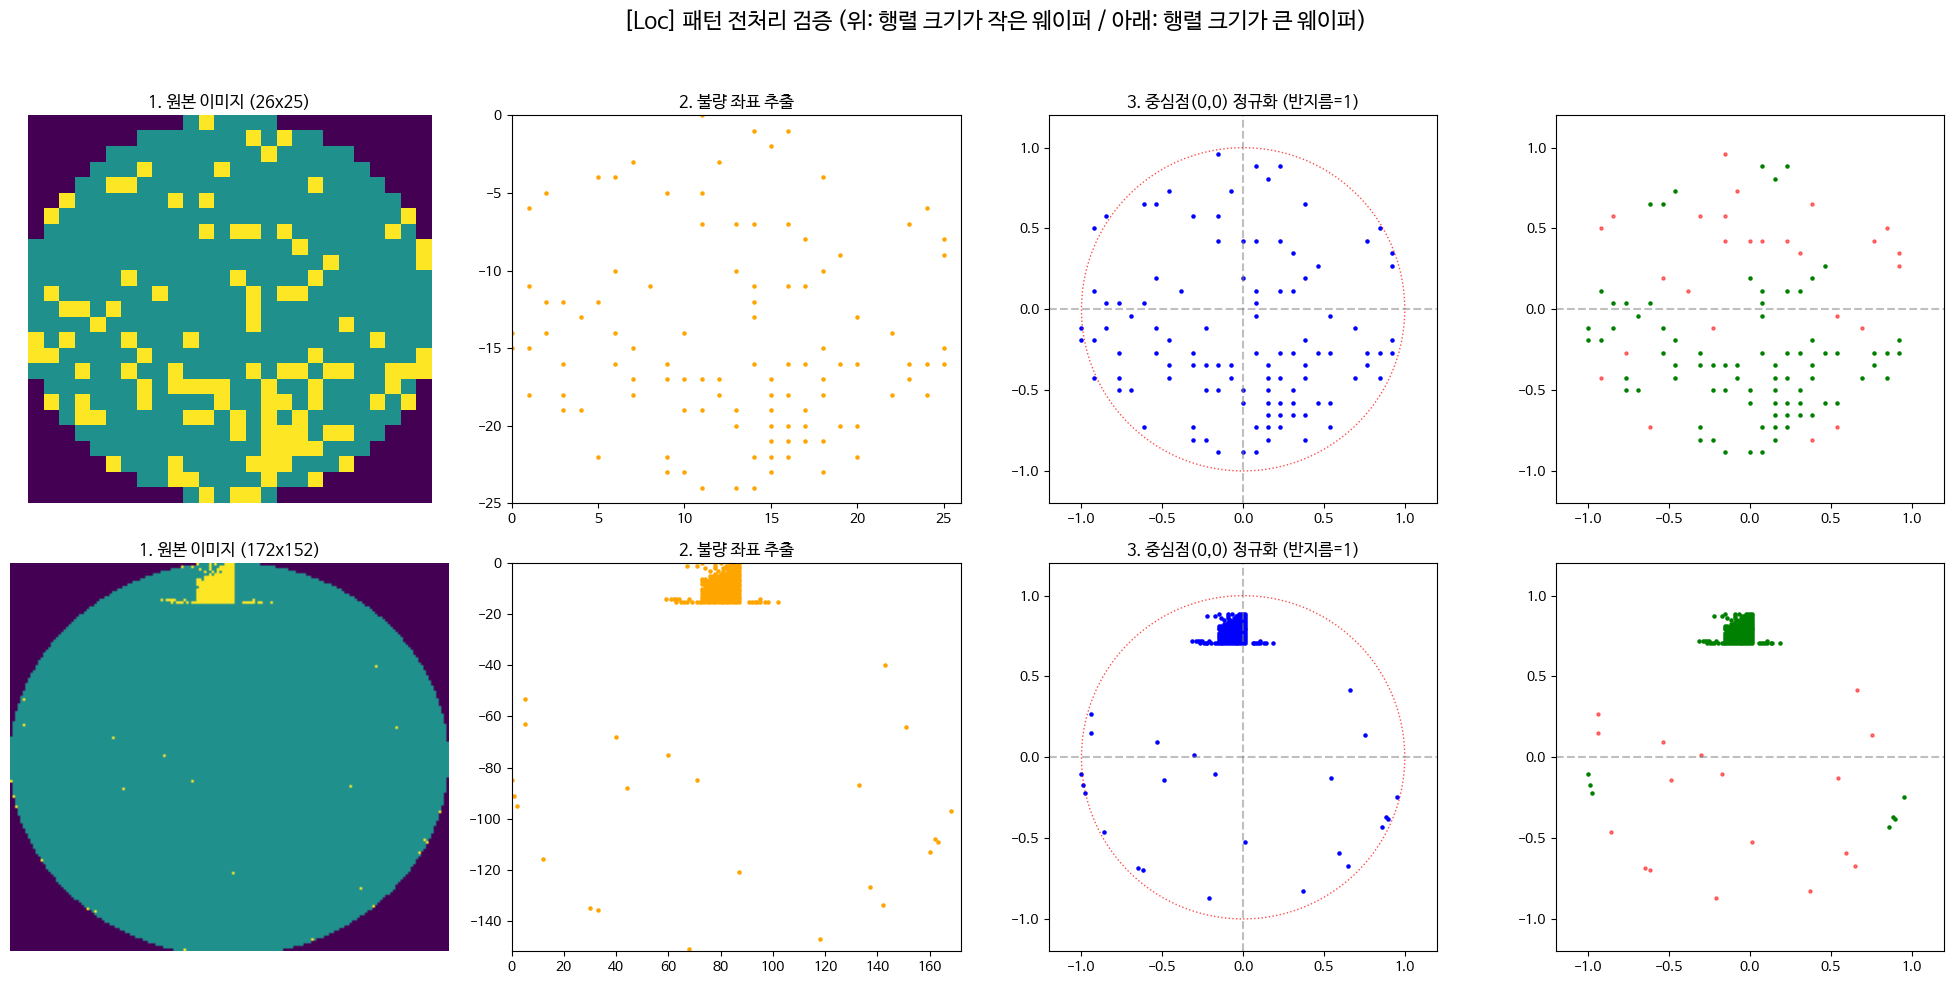

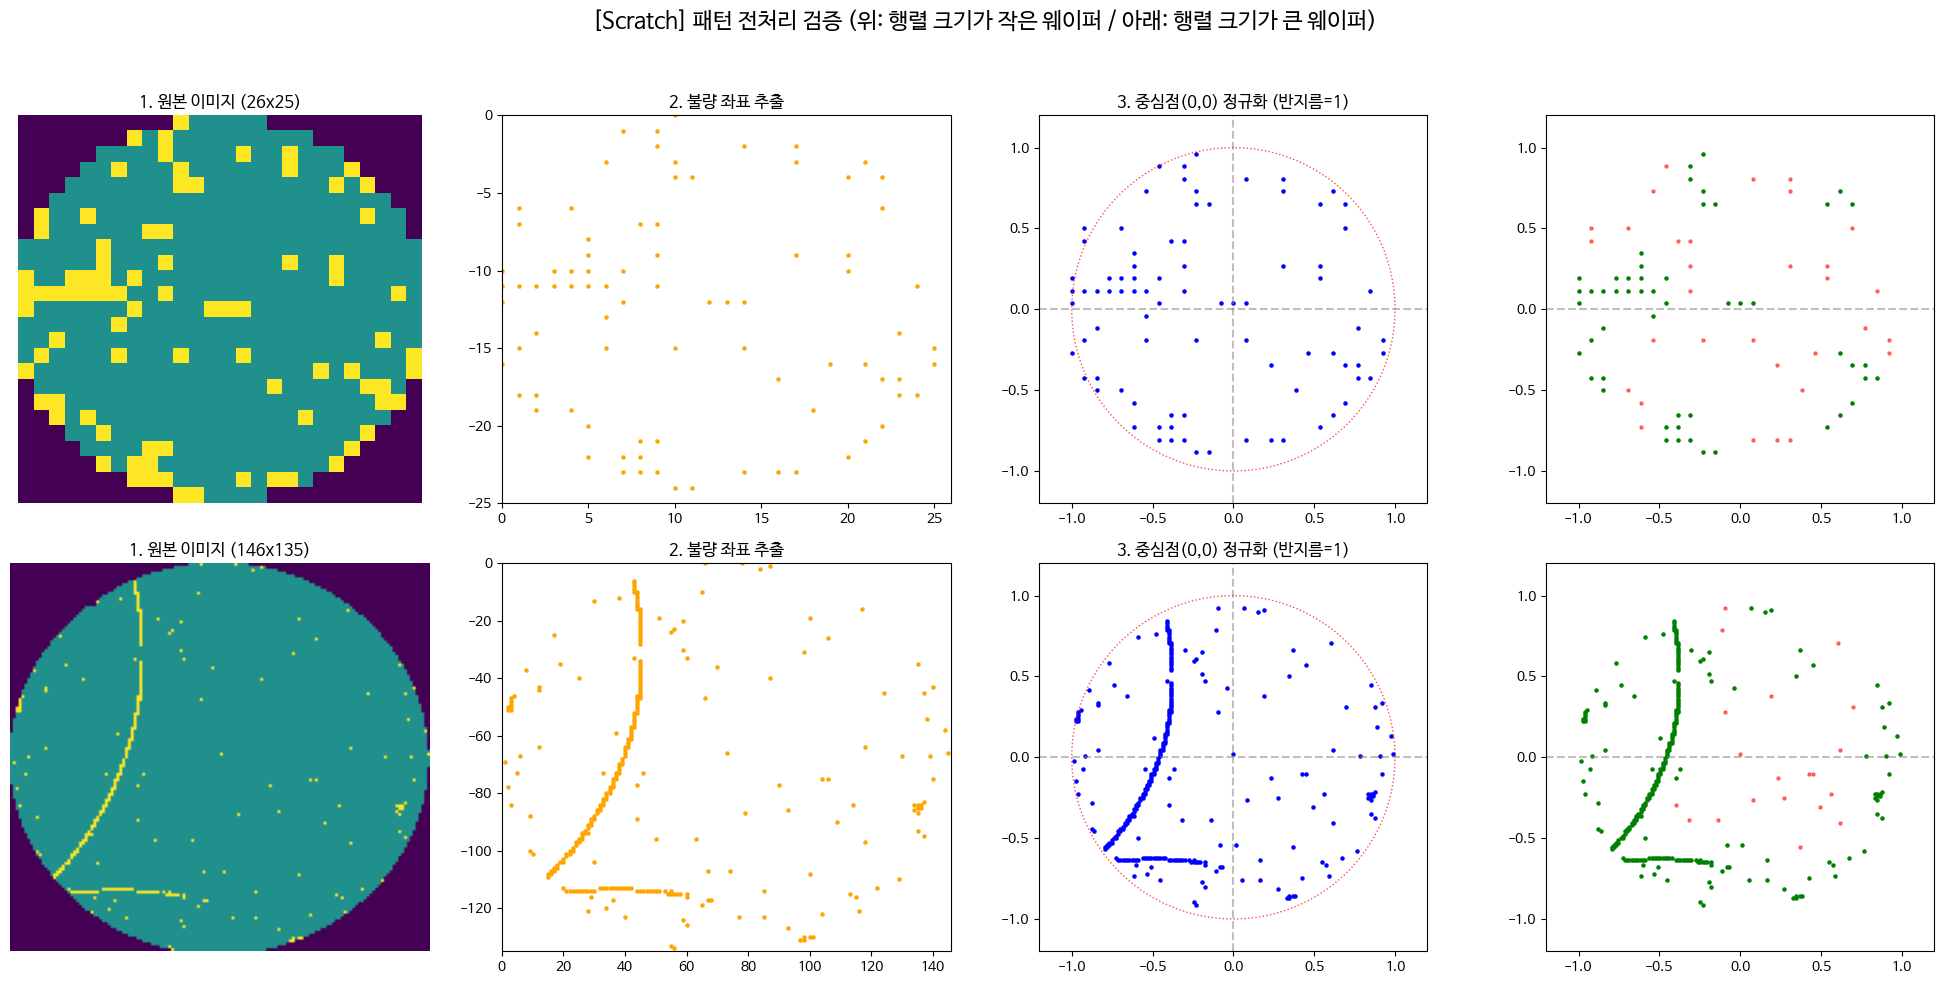

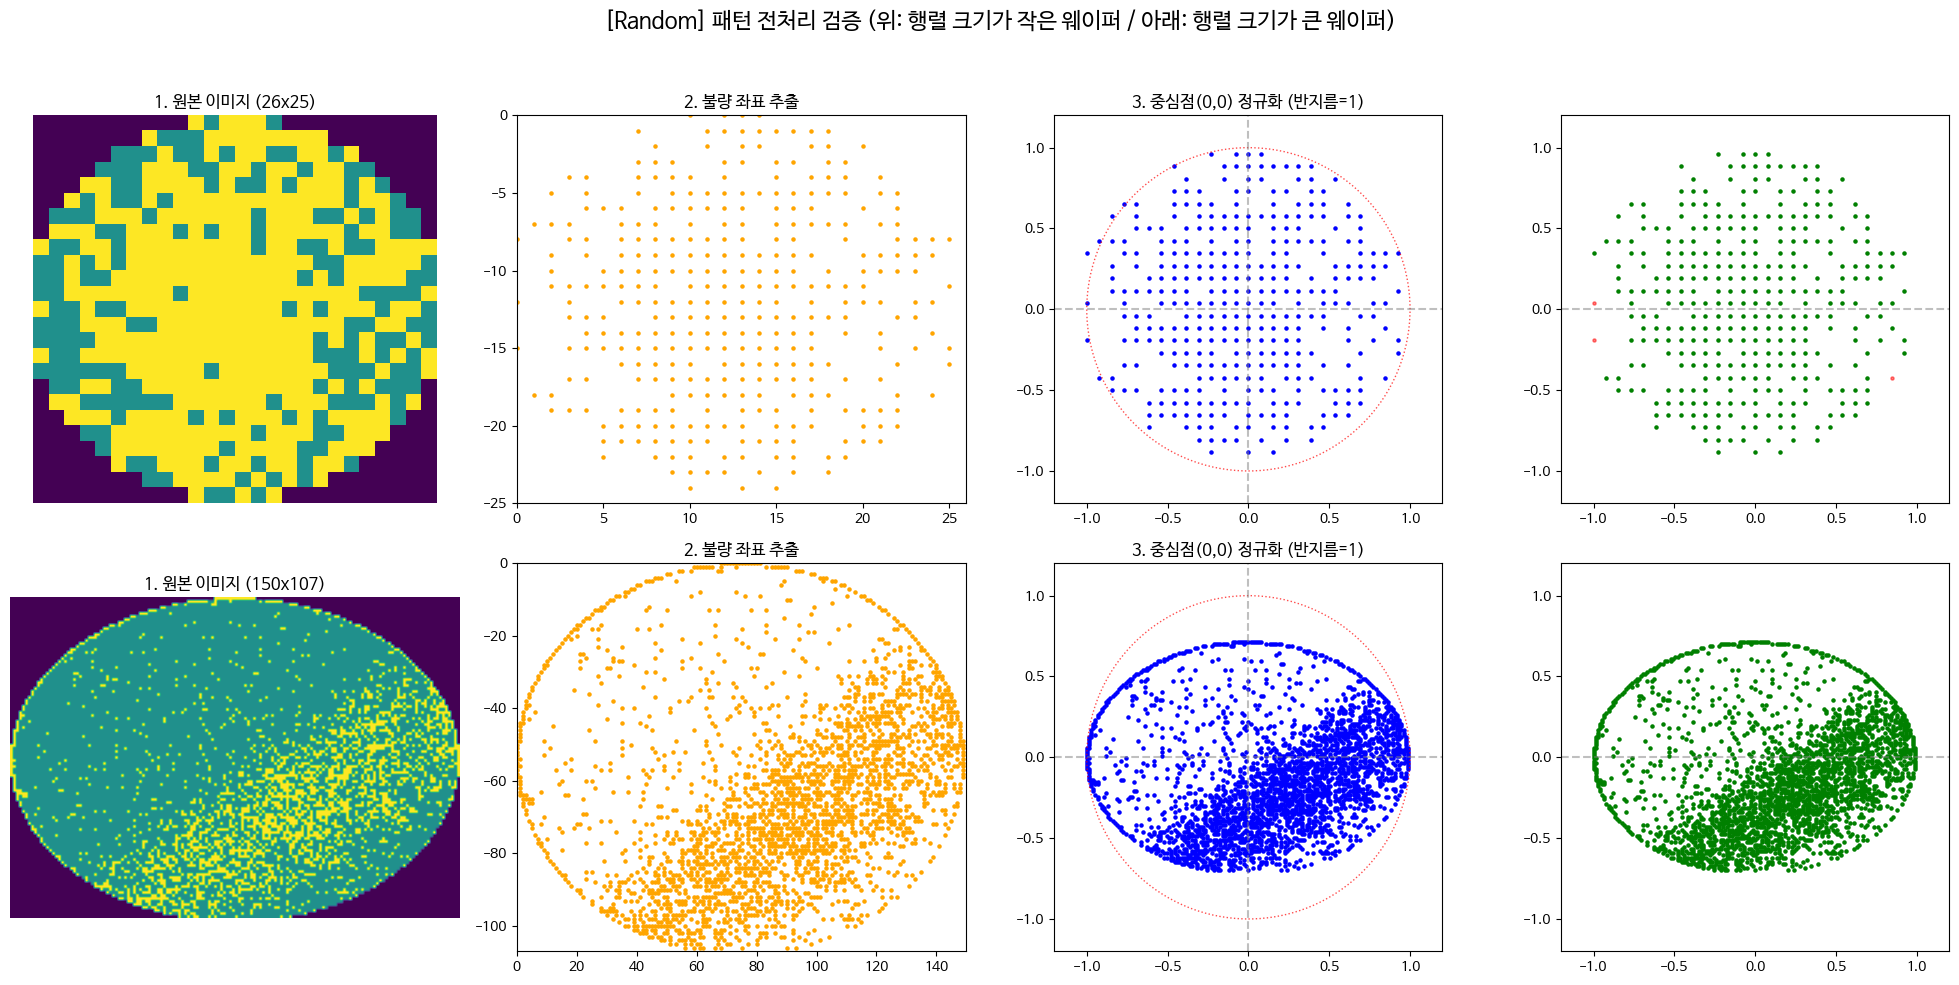

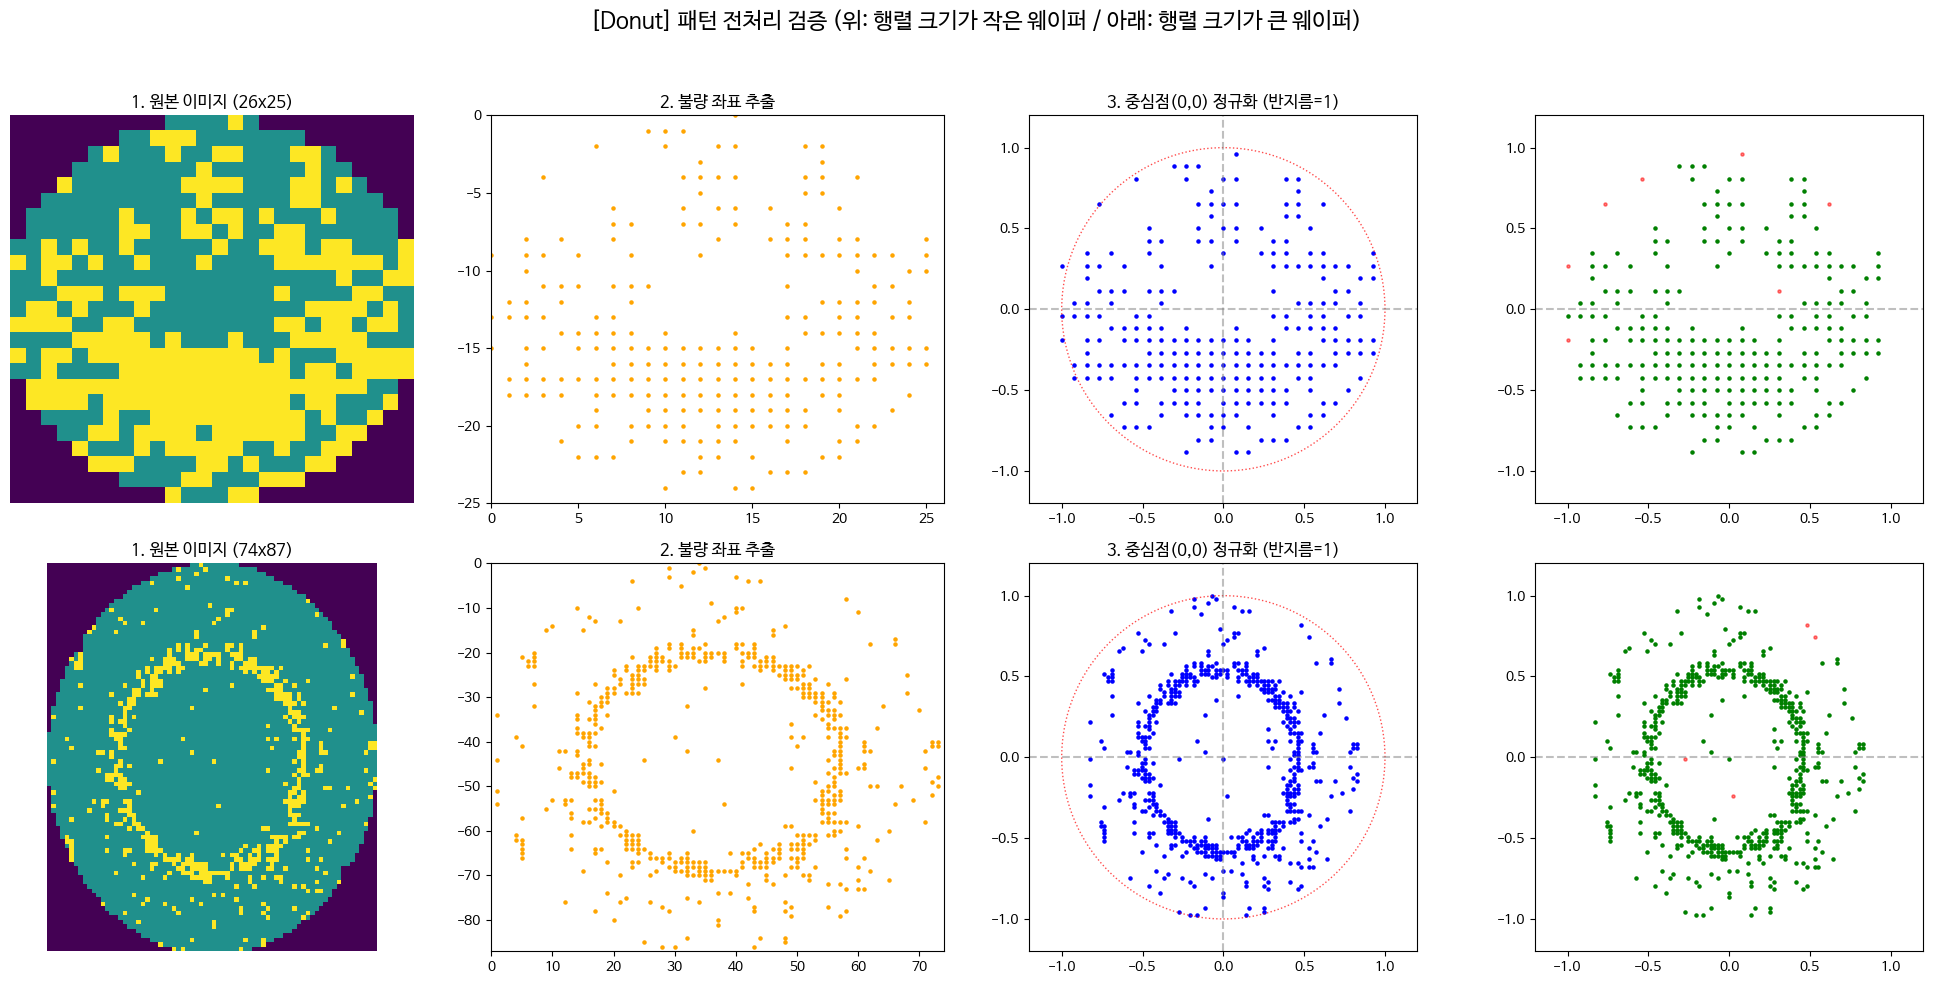

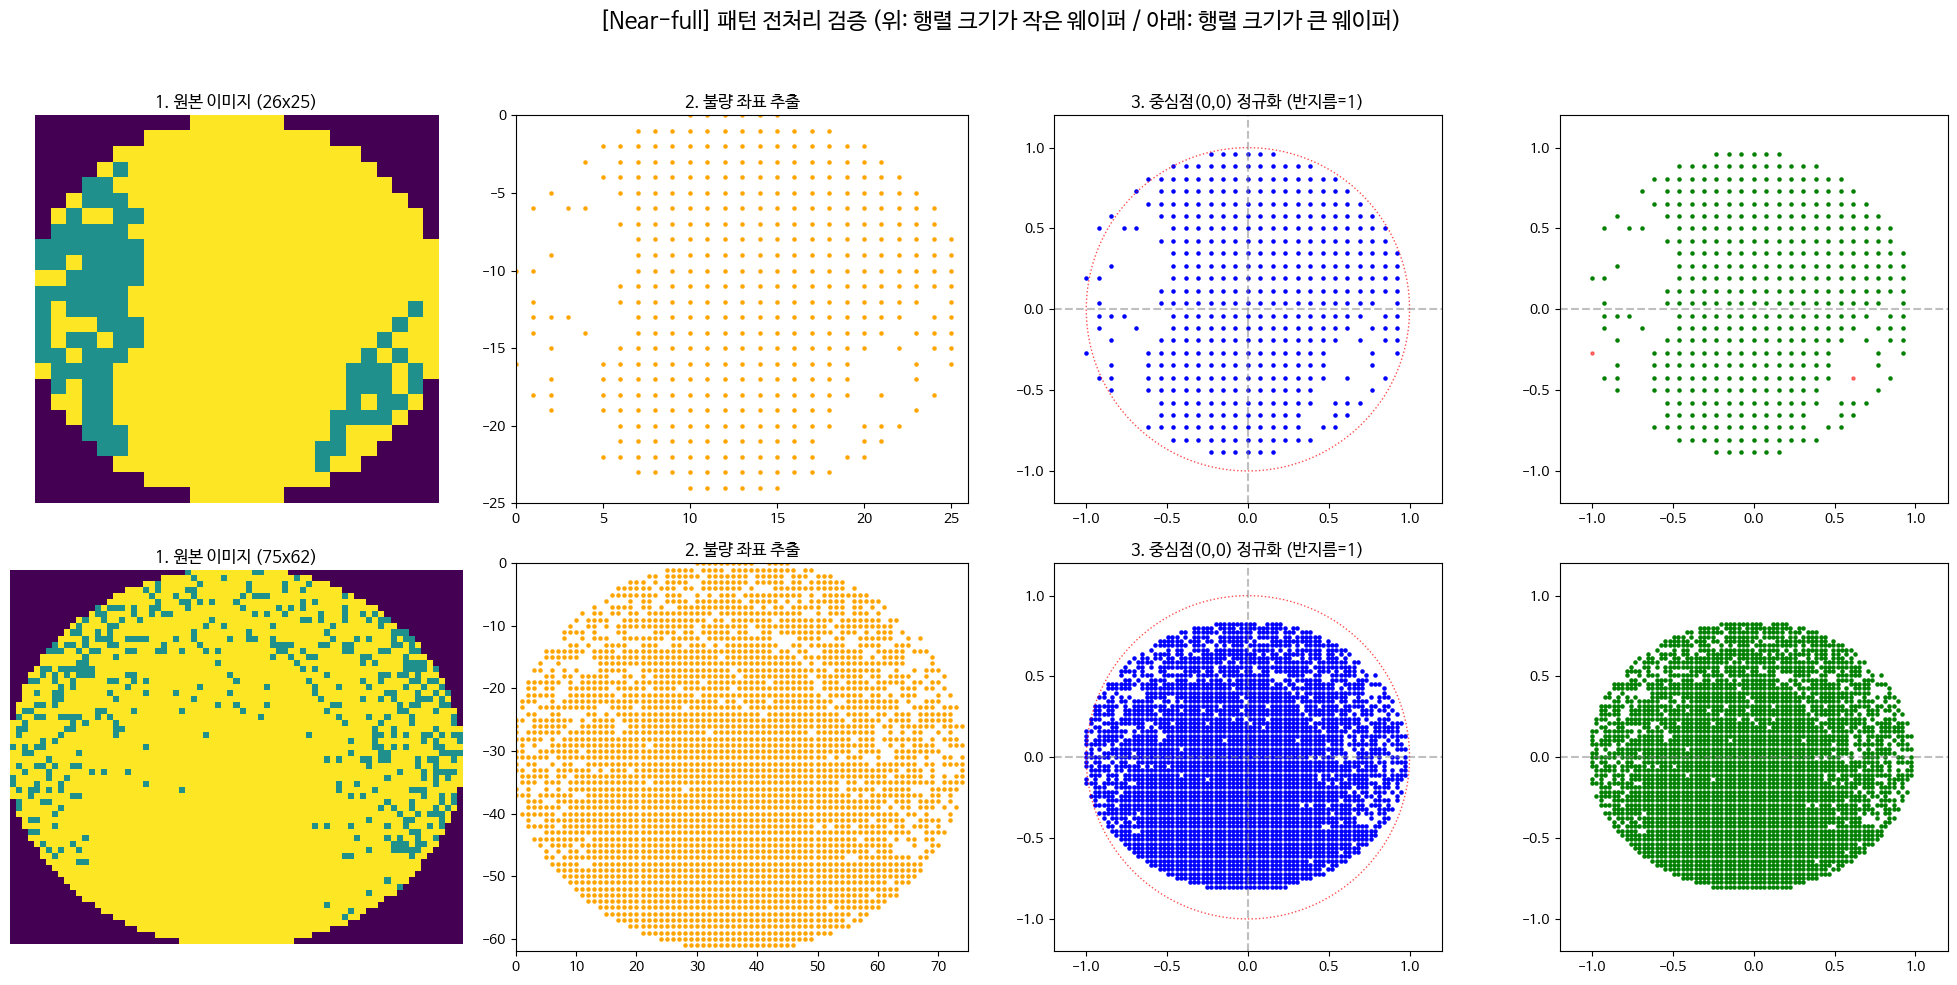

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import logging
from sklearn.cluster import DBSCAN
import warnings

# 1. 기본적인 파이썬 경고창 숨김
warnings.filterwarnings('ignore')

# 2. [핵심] Matplotlib 폰트 매니저의 경고(Warning) 메시지를 강제로 차단
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 3. 코랩 폰트 경로를 직접 지정하여 강제 로드 (런타임 재시작 이슈 방지)
try:
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumBarunGothic')
except Exception:
    print("안내: 나눔폰트를 찾을 수 없어 기본 폰트로 시각화를 진행합니다.")
    pass


def visualize_preprocessing_sanity_check(df, defect_types=['Edge-Ring', 'Center', 'Scratch', 'Random']):
    """
    각 결함 패턴별로 가장 작은 웨이퍼와 큰 웨이퍼를 추출하여
    전처리 4단계 과정을 시각적으로 비교 검증하는 함수
    """
    # 웨이퍼의 면적(크기)을 계산하여 임시 컬럼 생성
    df['wafer_area'] = df['waferMap'].apply(lambda x: x.shape[0] * x.shape[1])

    for defect in defect_types:
        subset = df[df['failureType'] == defect].sort_values('wafer_area')
        if len(subset) < 2:
            continue

        # 가장 작은 웨이퍼와 가장 큰 웨이퍼 맵 추출
        small_wafer = subset.iloc[0]['waferMap']
        large_wafer = subset.iloc[-1]['waferMap']

        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        fig.suptitle(f"🔍 [{defect}] 패턴 전처리 검증 (위: 행렬 크기가 작은 웨이퍼 / 아래: 행렬 크기가 큰 웨이퍼)", fontsize=16, fontweight='bold')

        wafers = [small_wafer, large_wafer]

        for i, wafer_map in enumerate(wafers):
            h, w = wafer_map.shape
            cy, cx = h / 2.0, w / 2.0
            rmax = max(cx, cy)

            # [단계 1] 원본 행렬 이미지
            axes[i, 0].imshow(wafer_map, cmap='viridis')
            axes[i, 0].set_title(f"1. 원본 이미지 ({w}x{h})")
            axes[i, 0].axis('off')

            # [단계 2] 불량 다이 좌표만 추출
            y_idx, x_idx = np.where(wafer_map == 2)
            axes[i, 1].scatter(x_idx, -y_idx, c='orange', s=5)
            axes[i, 1].set_xlim(0, w); axes[i, 1].set_ylim(-h, 0)
            axes[i, 1].set_title("2. 불량 좌표 추출")

            # [단계 3] 영점 조정 및 정규화
            x_norm = (x_idx - cx) / rmax
            y_norm = -(y_idx - cy) / rmax
            axes[i, 2].scatter(x_norm, y_norm, c='blue', s=5)
            axes[i, 2].set_xlim(-1.2, 1.2); axes[i, 2].set_ylim(-1.2, 1.2)

            # 👇 이 줄을 추가하여 X, Y축 비율을 1:1로 고정합니다.
            axes[i, 2].set_aspect('equal')

            axes[i, 2].axhline(0, color='grey', linestyle='--', alpha=0.5)
            axes[i, 2].axvline(0, color='grey', linestyle='--', alpha=0.5)
            circle = plt.Circle((0, 0), 1, color='red', fill=False, linestyle=':', alpha=0.7)
            axes[i, 2].add_patch(circle)
            axes[i, 2].set_title("3. 중심점(0,0) 정규화 (반지름=1)")

            # [단계 4] DBSCAN 노이즈 필터링
            if len(x_norm) > 0:
                coords = np.column_stack((x_norm, y_norm))
                db = DBSCAN(eps=0.15, min_samples=3).fit(coords)
                mask = db.labels_ != -1

                axes[i, 3].scatter(x_norm[mask], y_norm[mask], c='green', s=5, label='유효 패턴 (Valid)')
                axes[i, 3].scatter(x_norm[~mask], y_norm[~mask], c='red', s=5, alpha=0.5, label='제거된 노이즈')

            axes[i, 3].set_xlim(-1.2, 1.2); axes[i, 3].set_ylim(-1.2, 1.2)

            # 👇 여기도 추가해 줍니다.
            axes[i, 3].set_aspect('equal')

            axes[i, 3].axhline(0, color='grey', linestyle='--', alpha=0.5)

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

# ==========================================
# 실행 부분
# ==========================================
if __name__ == "__main__":
    # 코랩 환경에 업로드된 pkl 파일의 정확한 경로를 지정해 주세요
    file_path = '/content/drive/MyDrive/ACK2026_Wafer/MIR-WM811K/MIR-WM811K/Python/WM811K_defects.pkl'

    print("불량 데이터셋 로드 중...")
    try:
        df_defects = pd.read_pickle(file_path)
        patterns_to_check = ['Edge-Ring', 'Edge-Loc', 'Center', 'Loc', 'Scratch', 'Random', 'Donut', 'Near-full' ]
        visualize_preprocessing_sanity_check(df_defects, patterns_to_check)

    except FileNotFoundError:
        print(f"에러: '{file_path}' 파일을 찾을 수 없습니다. 코랩 파일 탭에 업로드되었는지 확인해 주세요.")